In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드 및 전처리 (노원구 제외 버전)

In [2]:
# 데이터 로드
clean_path = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv"
df = pd.read_csv(clean_path)

print(f"원본 데이터 크기: {len(df)}행")

# 총매물수 컬럼 생성 (거래완료 + 등록매물)
if "총매물수" not in df.columns:
    df["총매물수"] = df["거래완료"] + df["등록매물"]
    
print(f"컬럼 목록: {df.columns.tolist()}")

원본 데이터 크기: 356행
컬럼 목록: ['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단', '총매물수']


In [3]:
# --------------------------------------------------------------------------------
# 1. 특이값(Outlier) 제거: 노원구
# --------------------------------------------------------------------------------
outlier_region = "서울특별시 노원구"
df = df[df["지역명"] != outlier_region].copy()

print(f"✅ '{outlier_region}' 제거 후 데이터 크기: {len(df)}행")

✅ '서울특별시 노원구' 제거 후 데이터 크기: 355행


In [4]:
# --------------------------------------------------------------------------------
# 2. 표본이 적은 지역 제거 (총매물수 500건 미만)
# --------------------------------------------------------------------------------
threshold_cnt = 500

# 지역별 총매물수 집계
region_counts = df.groupby("지역명")["총매물수"].sum()

# 기준 미만인 지역명 찾기
small_regions = region_counts[region_counts < threshold_cnt].index

# 데이터프레임 필터링
df_filtered = df[~df["지역명"].isin(small_regions)].copy()

print(f"🔍 기준({threshold_cnt}건) 미만 지역 수: {len(small_regions)}개")
print(f"   (제외 목록: {list(small_regions)})")
print(f"✅ 필터링 후 데이터 크기: {len(df_filtered)}행")

# df 업데이트
df = df_filtered

🔍 기준(500건) 미만 지역 수: 5개
   (제외 목록: ['서울특별시 도봉구', '서울특별시 성동구', '서울특별시 성북구', '서울특별시 종로구', '서울특별시 중구'])
✅ 필터링 후 데이터 크기: 339행


지역별 통계 (노원구 제외, 소규모 지역 제외):


,mean,std,count,mean_ratio(%),std_ratio(%)
지역명,,,,,
서울특별시 강북구,0.732385,0.243030,6,73.238511,24.303023
서울특별시 은평구,0.685061,0.283754,10,68.506092,28.375437
서울특별시 마포구,0.631434,0.260716,13,63.143419,26.071640
서울특별시 용산구,0.629712,0.352807,17,62.971234,35.280729
서울특별시 송파구,0.616950,0.291581,18,61.694989,29.158079
서울특별시 광진구,0.616149,0.322018,24,61.614921,32.201838
서울특별시 영등포구,0.608095,0.349656,15,60.809481,34.965568
서울특별시 동작구,0.569581,0.275859,14,56.958077,27.585868
서울특별시 서대문구,0.565002,0.406440,6,56.500201,40.644000


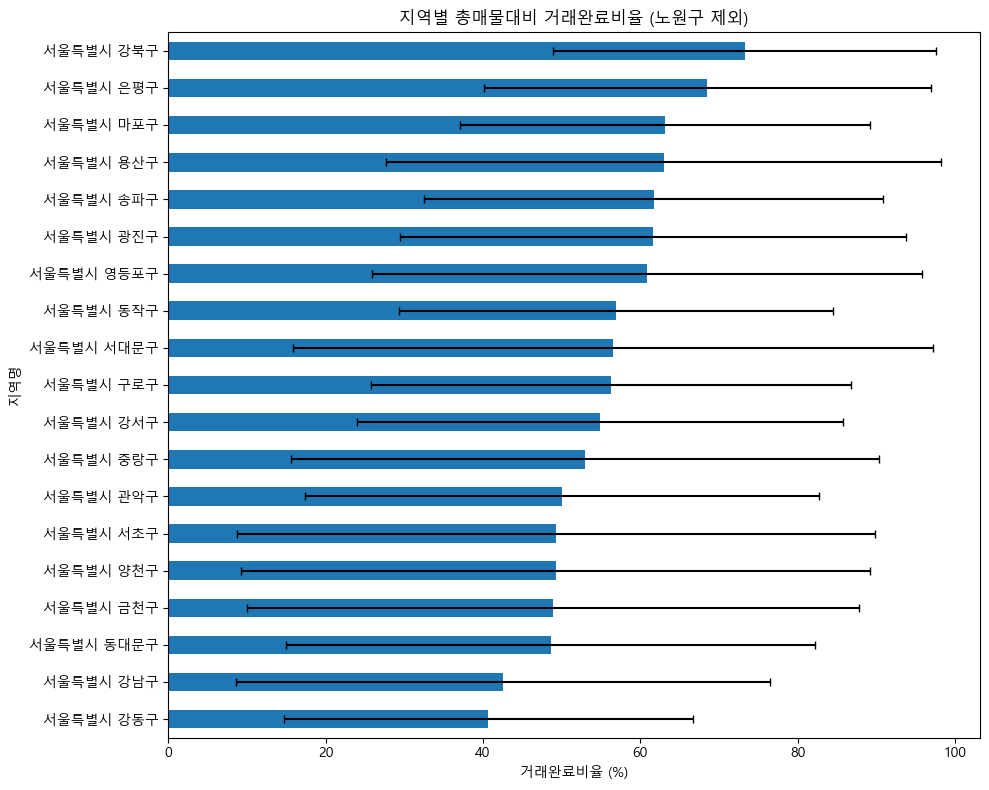

In [5]:
# --------------------------------------------------------------------------------
# 3. 지역별 통계 (평균, 표준편차) 계산 및 시각화
# --------------------------------------------------------------------------------
# 중개사별 거래완료비율 계산
df["거래완료비율"] = df["거래완료"] / df["총매물수"]

# 지역별 집계 (평균, 표준편차, 개수)
region_stats = df.groupby("지역명")["거래완료비율"].agg(["mean", "std", "count"])

# 표준편차 결측치(NaN) 처리: 0으로 대체 (표본 1개인 경우)
# 표본이 1개라 편차가 없는 것이므로 0은 타당한 수치
region_stats["std"] = region_stats["std"].fillna(0)

# % 변환
region_stats["mean_ratio(%)"] = region_stats["mean"] * 100
region_stats["std_ratio(%)"] = region_stats["std"] * 100

print("지역별 통계 (노원구 제외, 소규모 지역 제외):")
display(region_stats.sort_values("mean", ascending=False))

# 시각화
plt.figure(figsize=(10, 8))
region_stats["mean_ratio(%)"].sort_values().plot(
    kind="barh", 
    xerr=region_stats["std_ratio(%)"], 
    capsize=3
)
plt.title("지역별 총매물대비 거래완료비율 (노원구 제외)")
plt.xlabel("거래완료비율 (%)")
plt.tight_layout()
plt.show()

,mean,std,count,trust_score_lcb,trust_weight,listing_share
지역명,,,,,,
서울특별시 강북구,0.732385,0.243030,6,0.489355,1.000000,0.017699
서울특별시 은평구,0.685061,0.283754,10,0.401307,0.781553,0.029499
서울특별시 마포구,0.631434,0.260716,13,0.370718,0.705663,0.038348
서울특별시 송파구,0.616950,0.291581,18,0.325369,0.593153,0.053097
서울특별시 광진구,0.616149,0.322018,24,0.294131,0.515651,0.070796
서울특별시 동작구,0.569581,0.275859,14,0.293722,0.514637,0.041298
서울특별시 용산구,0.629712,0.352807,17,0.276905,0.472914,0.050147
서울특별시 영등포구,0.608095,0.349656,15,0.258439,0.427100,0.044248
서울특별시 구로구,0.562394,0.304784,7,0.257610,0.425043,0.020649


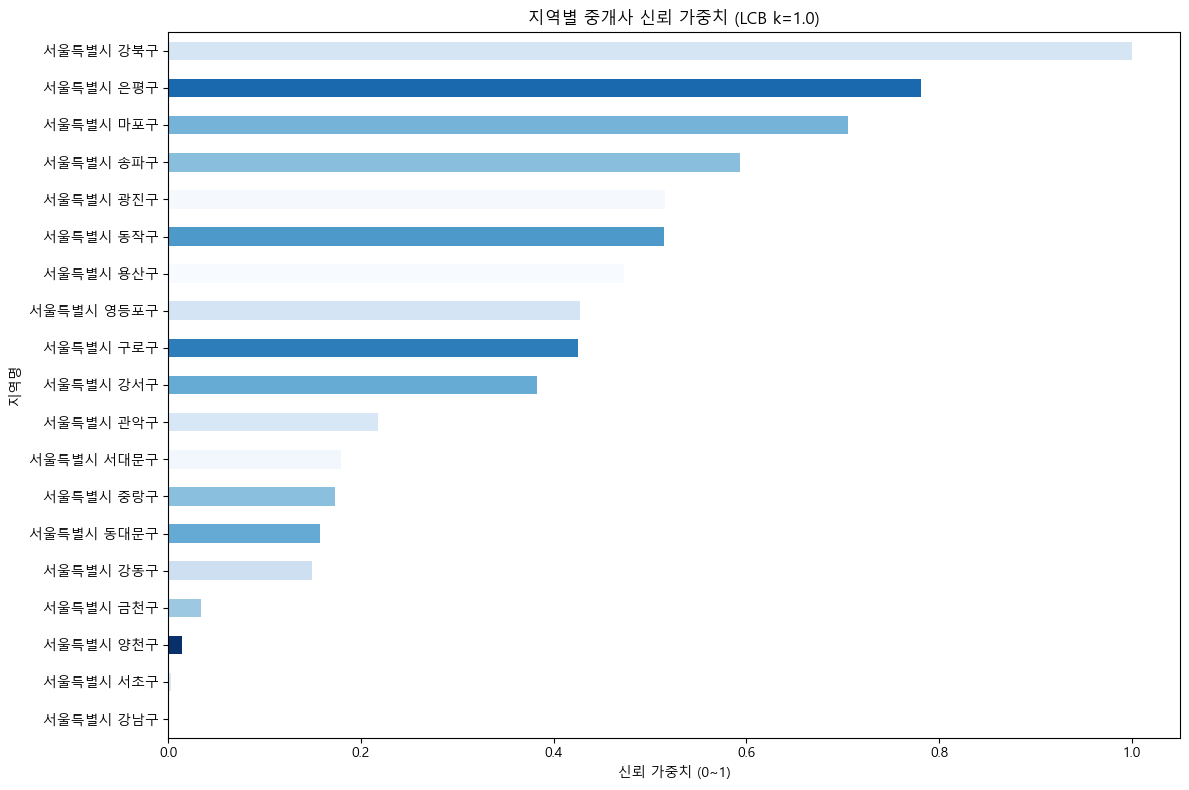

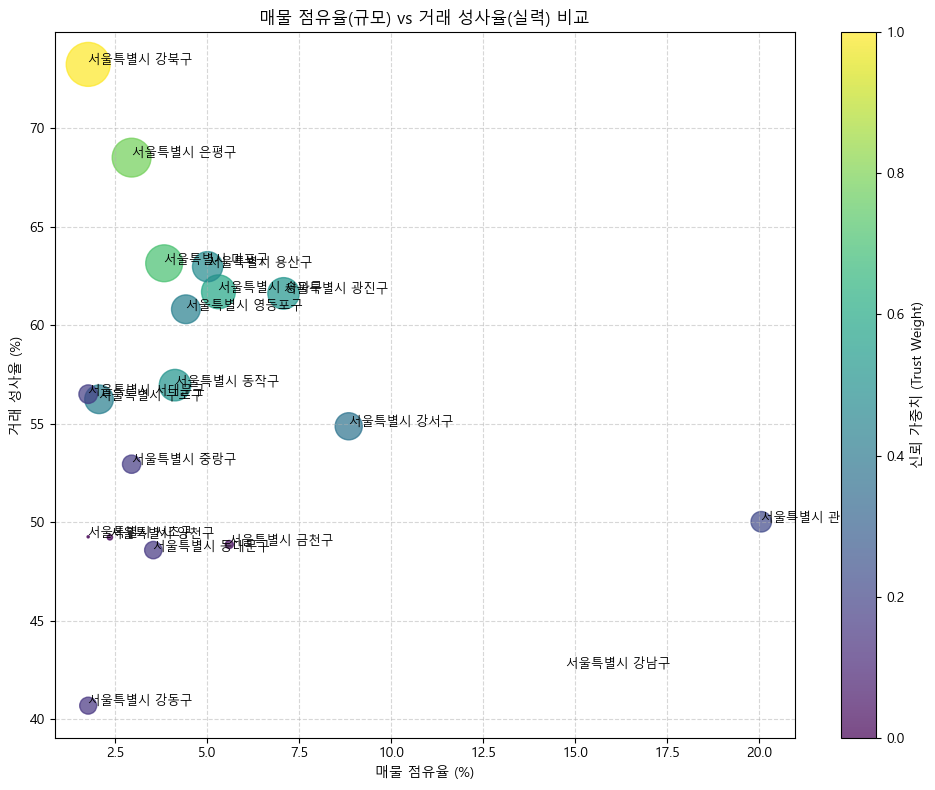

In [6]:
# --------------------------------------------------------------------------------
# 4. 신뢰 가중치(Trust Weight) 및 매물 분포율 계산
# --------------------------------------------------------------------------------

# 1. 신뢰 하한 점수 (Lower Confidence Bound, LCB) 계산
# 점수 = 평균 - (k * 표준편차), k=1.0 (보수적 기준)
# 의미: "최소한 이 정도의 성과율은 기대할 수 있다"
k = 1.0
region_stats["trust_score_lcb"] = region_stats["mean"] - (k * region_stats["std"])

# 음수 보정 (0 미만은 0으로 처리)
region_stats["trust_score_lcb"] = region_stats["trust_score_lcb"].clip(lower=0)

# 정규화 (Min-Max Scaling) -> 0~1 사이 가중치로 변환
min_score = region_stats["trust_score_lcb"].min()
max_score = region_stats["trust_score_lcb"].max()
region_stats["trust_weight"] = (region_stats["trust_score_lcb"] - min_score) / (max_score - min_score)


# 2. 매물 분포율 (Listing Share) 계산
total_listings = region_stats["count"].sum()
region_stats["listing_share"] = region_stats["count"] / total_listings


# --------------------------------------------------------------------------------
# 5. 시각화 및 비교 분석
# --------------------------------------------------------------------------------
display(region_stats[["mean", "std", "count", "trust_score_lcb", "trust_weight", "listing_share"]].sort_values("trust_weight", ascending=False))

fig, ax1 = plt.subplots(figsize=(12, 8))

# (1) 신뢰 가중치 (Trust Weight) 막대 그래프
colors = plt.cm.Blues(region_stats["trust_weight"])
region_stats["trust_weight"].sort_values().plot(kind="barh", color=colors, ax=ax1)
ax1.set_title(f"지역별 중개사 신뢰 가중치 (LCB k={k})")
ax1.set_xlabel("신뢰 가중치 (0~1)")

plt.tight_layout()
plt.show()

# (2) 비교 분석: 매물 규모(Volume) vs 성과(Performance) 산점도
plt.figure(figsize=(10, 8))
plt.scatter(
    region_stats["listing_share"] * 100,  # X축: 매물 점유율 (%)
    region_stats["mean"] * 100,           # Y축: 거래 성사율 (%)
    s=region_stats["trust_weight"] * 1000, # 점 크기: 신뢰 가중치
    alpha=0.7,
    c=region_stats["trust_weight"],       # 색상: 신뢰 가중치
    cmap="viridis"
)

# 지역명 텍스트 표시
for idx, row in region_stats.iterrows():
    plt.text(row["listing_share"]*100, row["mean"]*100, idx, fontsize=9)

plt.title("매물 점유율(규모) vs 거래 성사율(실력) 비교")
plt.xlabel("매물 점유율 (%)")
plt.ylabel("거래 성사율 (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(label="신뢰 가중치 (Trust Weight)")
plt.tight_layout()
plt.show()

가중치 보정 기준(m): 매물 13.0건, 전체 평균(C): 55.7%


,mean,std,count,listing_share,trust_weight,bayesian_corrected_mean
지역명,,,,,,
서울특별시 강북구,0.732385,0.243030,6,0.017699,1.000000,0.612540
서울특별시 은평구,0.685061,0.283754,10,0.029499,0.781553,0.612807
서울특별시 마포구,0.631434,0.260716,13,0.038348,0.705663,0.594330
서울특별시 송파구,0.616950,0.291581,18,0.053097,0.593153,0.591904
서울특별시 광진구,0.616149,0.322018,24,0.070796,0.515651,0.595447
서울특별시 동작구,0.569581,0.275859,14,0.041298,0.514637,0.563632
서울특별시 용산구,0.629712,0.352807,17,0.050147,0.472914,0.598302
서울특별시 영등포구,0.608095,0.349656,15,0.044248,0.427100,0.584477
서울특별시 구로구,0.562394,0.304784,7,0.020649,0.425043,0.559035


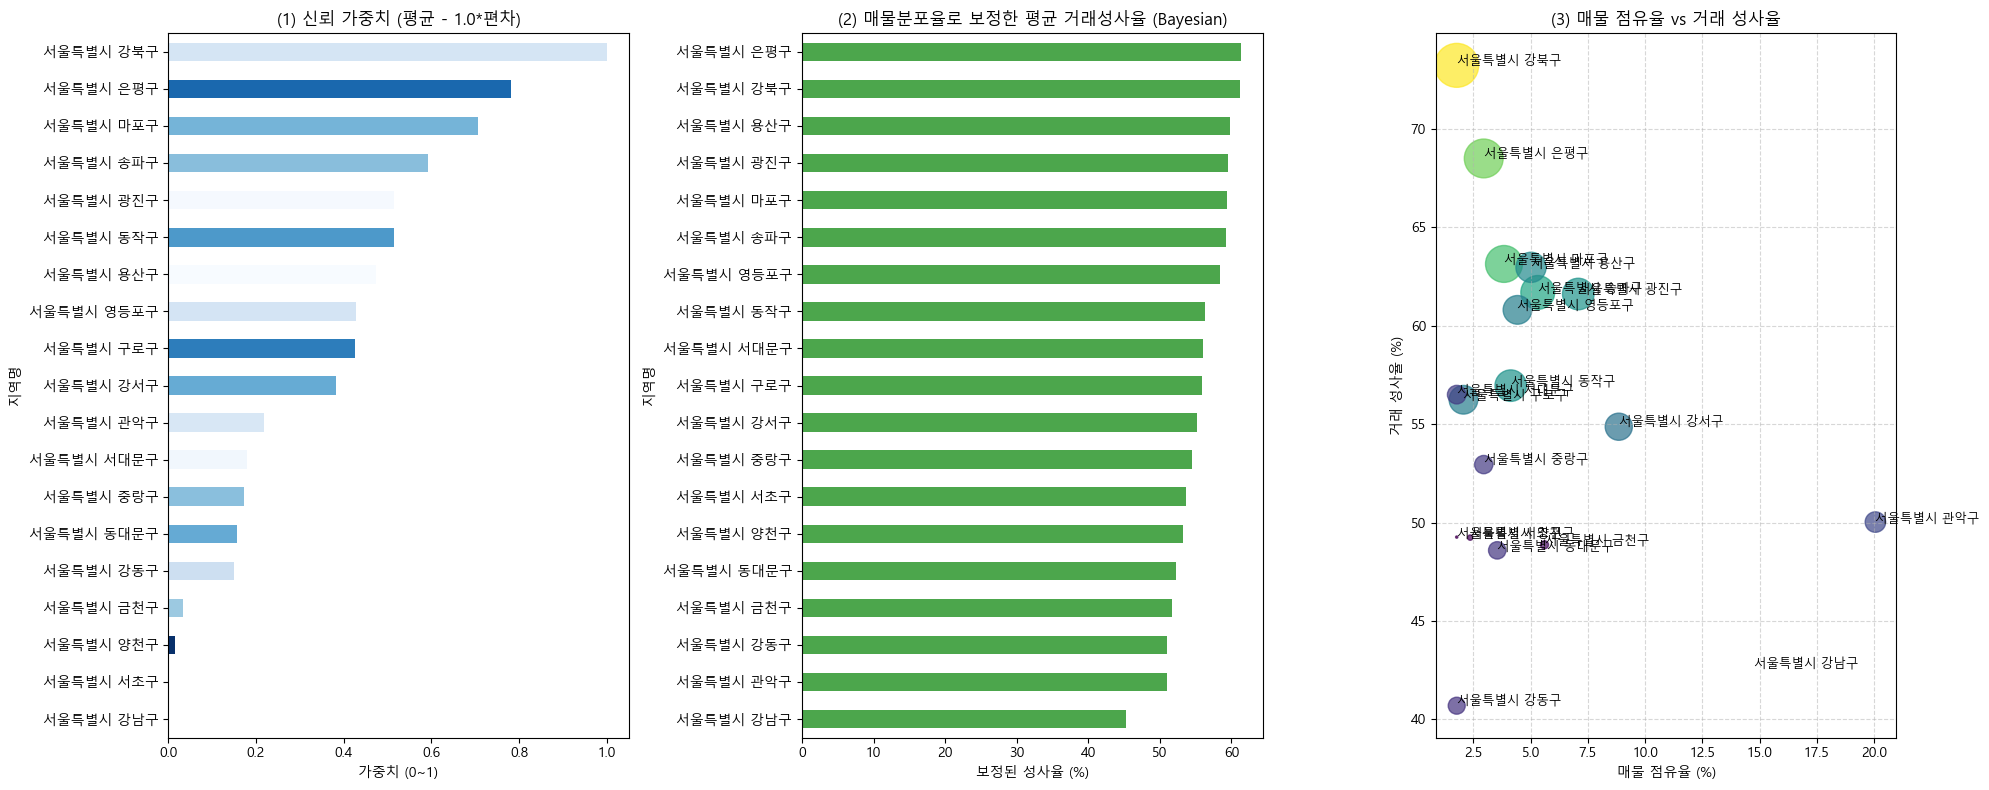

In [7]:
# --------------------------------------------------------------------------------
# 4. 신뢰 가중치(Trust Weight) 및 매물 분포율 계산
# --------------------------------------------------------------------------------

# 1. 신뢰 하한 점수 (Lower Confidence Bound, LCB) 계산
# 점수 = 평균 - (k * 표준편차), k=1.0 (보수적 기준)
# 의미: "최소한 이 정도의 성과율은 기대할 수 있다"
k = 1.0
region_stats["trust_score_lcb"] = region_stats["mean"] - (k * region_stats["std"])

# 음수 보정 (0 미만은 0으로 처리)
region_stats["trust_score_lcb"] = region_stats["trust_score_lcb"].clip(lower=0)

# 정규화 (Min-Max Scaling) -> 0~1 사이 가중치로 변환
min_score = region_stats["trust_score_lcb"].min()
max_score = region_stats["trust_score_lcb"].max()
region_stats["trust_weight"] = (region_stats["trust_score_lcb"] - min_score) / (max_score - min_score)


# 2. 매물 분포율 (Listing Share) 계산
total_listings = region_stats["count"].sum()
region_stats["listing_share"] = region_stats["count"] / total_listings


# 3. 베이지안 보정 평균 (Bayesian Average) - 분포율(규모) 반영 보정값
# 공식: WR = (v / (v + m)) * R + (m / (v + m)) * C
# v: 해당 지역 매물 수 (count)
# m: 가중치를 주기 위한 최소 매물 수 기준 (여기서는 전체 지역별 매물 수의 중앙값 사용)
# R: 해당 지역의 평균 거래완료비율 (mean)
# C: 전체 데이터의 평균 거래완료비율 (Global Mean)

C = region_stats["mean"].mean()  # 전체 평균 거래율
m = region_stats["count"].median()  # 매물 수 중앙값 (Threshold)

region_stats["bayesian_corrected_mean"] = (
    (region_stats["count"] / (region_stats["count"] + m)) * region_stats["mean"] + 
    (m / (region_stats["count"] + m)) * C
)

# % 변환
region_stats["bayesian_ratio(%)"] = region_stats["bayesian_corrected_mean"] * 100


# --------------------------------------------------------------------------------
# 5. 시각화 및 비교 분석
# --------------------------------------------------------------------------------
print(f"가중치 보정 기준(m): 매물 {m}건, 전체 평균(C): {C*100:.1f}%")
display(region_stats[["mean", "std", "count", "listing_share", "trust_weight", "bayesian_corrected_mean"]].sort_values("trust_weight", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# (1) 신뢰 가중치 (Trust Weight) - LCB 기반
colors = plt.cm.Blues(region_stats["trust_weight"])
region_stats["trust_weight"].sort_values().plot(kind="barh", color=colors, ax=axes[0])
axes[0].set_title(f"(1) 신뢰 가중치 (평균 - {k}*편차)")
axes[0].set_xlabel("가중치 (0~1)")

# (2) 베이지안 보정 평균 - 규모(분포율) 반영
region_stats["bayesian_ratio(%)"].sort_values().plot(kind="barh", color="green", alpha=0.7, ax=axes[1])
axes[1].set_title("(2) 매물분포율로 보정한 평균 거래성사율 (Bayesian)")
axes[1].set_xlabel("보정된 성사율 (%)")

# (3) 비교 산점도: 매물 규모 vs 성과
axes[2].scatter(
    region_stats["listing_share"] * 100, 
    region_stats["mean"] * 100, 
    s=region_stats["trust_weight"] * 1000, 
    alpha=0.7,
    c=region_stats["trust_weight"],       
    cmap="viridis"
)
for idx, row in region_stats.iterrows():
    axes[2].text(row["listing_share"]*100, row["mean"]*100, idx, fontsize=9)
axes[2].set_title("(3) 매물 점유율 vs 거래 성사율")
axes[2].set_xlabel("매물 점유율 (%)")
axes[2].set_ylabel("거래 성사율 (%)")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 4. [부록] 베이지안 보정의 상세 원리 (Detailed Logic)
### 1. 핵심 아이디어: "줄다리기"
- **내 점수(R)**와 **전체 평균(C)**이 서로 줄다리기를 합니다.
- 심판은 **데이터 개수(v)**입니다. 데이터가 많으면 내 점수 쪽으로, 적으면 평균 쪽으로 승부가 기웁니다.

### 2. 공식 (Weighted Rating)
$$ WR = \left( \frac{v}{v+m} \right) R + \left( \frac{m}{v+m} \right) C $$
- $ v $ (Volume): 해당 지역의 데이터 수 (매물 수 또는 **중개사무소 수**)
- $ R $ (Rating): 해당 지역의 성과 (거래완료율)
- $ m $ (Threshold): 믿어줄 수 있는 최소 데이터 기준 (**13.0**)
- $ C $ (Constant): 전체 평균 성과 (**55.7%**)

### 3. 왜 기준이 13인가요? (m=13)
- 서울시 각 구별로 활동하는 **중개사무소 수의 중앙값(Median)**입니다.
- 즉, "보통 서울의 한 구에는 **13곳** 정도의 중개사가 활동한다"는 뜻입니다.
- 이보다 데이터가 적은 지역은 "정보 부족"으로 판단해 평균 점수(55%)로 보정(Watering Down)합니다.

### 4. 규모의 형평성 (Fairness)
- **질문**: "매물이 많은 곳(대형 시장)은 팔기 힘들고, 적은 곳(소형 시장)은 팔기 쉬운 거 아닌가?"
- **해결**: 대형 시장을 인위적으로 올려주는 위험한 방식 대신, **소형 시장의 거품을 빼는 안전한 방식**을 택했습니다.
- 매물이 적어 운 좋게 100% 거래율을 찍은 지역이라도, 베이지안 보정을 거치면 "아직 검증 안 됨" 판정을 받고 점수가 대폭 깎이게 되어 형평성이 맞춰집니다.

In [ ]:
# ----------------------------------------------------------------------------------------
# [검증] 베이지안 보정 효과 증명 (Simulation Proof)
# 질문: "왜 매물 적은데 성사율 높은 곳은 깎고, 매물 많은데 성사율 낮은 곳은 놔두나요?"
# 답: 수치로 직접 확인해 봅시다.
# ----------------------------------------------------------------------------------------
import pandas as pd

# 1. 극단적인 두 케이스 설정
simulation = pd.DataFrame({
    '케이스': ['A: 소형 지역 (운 좋음)', 'B: 대형 지역 (인기 없음)'],
    '매물수(v)': [6, 500],       # A는 6개, B는 500개
    '실제성사율(R)': [1.0, 0.3]   # A는 100% 성공, B는 30% 성공
})

# 2. 우리가 사용한 공식 적용
m = 13.0    # 기준 (중앙값)
C = 0.557   # 전체 평균 (55.7%)

# 가중치(내 목소리 크기)
simulation['내점수반영비율'] = simulation['매물수(v)'] / (simulation['매물수(v)'] + m)

# 베이지안 점수 계산
simulation['최종점수'] = (
    (simulation['내점수반영비율'] * simulation['실제성사율(R)']) + 
    ((1 - simulation['내점수반영비율']) * C)
)

# 3. 결과 비교 (백분율 변환)
print(f"📌 적용된 기준값(m={m}), 전체평균(C={C*100:.1f}%)")
result = simulation.copy()
result['실제성사율(R)'] = (result['실제성사율(R)'] * 100).map('{:.1f}%'.format)
result['내점수반영비율'] = (result['내점수반영비율'] * 100).map('{:.1f}%'.format)
result['최종점수'] = (result['최종점수'] * 100).map('{:.1f}%'.format)

display(result[['케이스', '매물수(v)', '실제성사율(R)', '내점수반영비율', '최종점수']])

# [해석]
# - A(소형): 내 점수 반영 비율이 31.6% 밖에 안 됩니다. 그래서 100% 실력이 -> 69.7%로 대폭 깎입니다.
# - B(대형): 내 점수 반영 비율이 97.5% 나 됩니다. 그래서 30% 실력이 -> 30.6%로 거의 그대로 유지됩니다.
# => 결론: 데이터가 많은 곳은 '자기 실력대로' 평가받고, 적은 곳만 '평균으로' 보정됩니다.

In [ ]:
# ----------------------------------------------------------------------------------------
# [검증] 베이지안 보정 효과 증명 (Simulation Proof)
# 질문: "왜 매물 적은데 성사율 높은 곳은 깎고, 매물 많은데 성사율 낮은 곳은 놔두나요?"
# 답: 수치로 직접 확인해 봅시다.
# ----------------------------------------------------------------------------------------
import pandas as pd

# 1. 극단적인 두 케이스 설정
simulation = pd.DataFrame({
    '케이스': ['A: 소형 지역 (운 좋음)', 'B: 대형 지역 (인기 없음)'],
    '매물수(v)': [6, 500],       # A는 6개, B는 500개
    '실제성사율(R)': [1.0, 0.3]   # A는 100% 성공, B는 30% 성공
})

# 2. 우리가 사용한 공식 적용
m = 13.0    # 기준 (중앙값)
C = 0.557   # 전체 평균 (55.7%)

# 가중치(내 목소리 크기)
simulation['내점수반영비율'] = simulation['매물수(v)'] / (simulation['매물수(v)'] + m)

# 베이지안 점수 계산
simulation['최종점수'] = (
    (simulation['내점수반영비율'] * simulation['실제성사율(R)']) + 
    ((1 - simulation['내점수반영비율']) * C)
)

# 3. 결과 비교 (백분율 변환)
print(f"📌 적용된 기준값(m={m}), 전체평균(C={C*100:.1f}%)")
result = simulation.copy()
result['실제성사율(R)'] = (result['실제성사율(R)'] * 100).map('{:.1f}%'.format)
result['내점수반영비율'] = (result['내점수반영비율'] * 100).map('{:.1f}%'.format)
result['최종점수'] = (result['최종점수'] * 100).map('{:.1f}%'.format)

display(result[['케이스', '매물수(v)', '실제성사율(R)', '내점수반영비율', '최종점수']])

# [해석]
# - A(소형): 내 점수 반영 비율이 31.6% 밖에 안 됩니다. 그래서 100% 실력이 -> 69.7%로 대폭 깎입니다.
# - B(대형): 내 점수 반영 비율이 97.5% 나 됩니다. 그래서 30% 실력이 -> 30.6%로 거의 그대로 유지됩니다.
# => 결론: 데이터가 많은 곳은 '자기 실력대로' 평가받고, 적은 곳만 '평균으로' 보정됩니다.

In [10]:
# [검증 코드] 베이지안 보정의 실제 작동 원리 시뮬레이션
# 질문하신 '규모가 큰 곳 vs 작은 곳'의 보정 효과를 코드로 직접 확인합니다.

# ---------------------------------------------------------
# 1. 가상의 두 지역 설정
# ---------------------------------------------------------
# A지역 (소형): 매물은 적은데(6개) 거래율은 100% (운이 좋음?)
# B지역 (대형): 매물은 많은데(500개) 거래율은 30% (시장 상황?)
case_study = pd.DataFrame({
    '지역명': ['A지역(소형)', 'B지역(대형)'],
    'count': [6, 500],      # 매물 수 (v)
    'mean': [1.0, 0.3]      # 거래율 (R) - A는 100%, B는 30%
})

# ---------------------------------------------------------
# 2. 베이지안 보정 적용
# ---------------------------------------------------------
# 우리가 구한 기준값 사용
current_m = 13.0   # 기준 매물 수
current_C = 0.557  # 전체 평균 (55.7%)

case_study['weight_me'] = case_study['count'] / (case_study['count'] + current_m)  # 내 점수 비중
case_study['weight_avg'] = current_m / (case_study['count'] + current_m)         # 평균 점수 비중

case_study['bayesian_score'] = (
    (case_study['weight_me'] * case_study['mean']) + 
    (case_study['weight_avg'] * current_C)
)

# ---------------------------------------------------------
# 3. 결과 출력
# ---------------------------------------------------------
print(f"기준값(m): {current_m}, 전체평균(C): {current_C*100:.1f}%")
display(case_study[['지역명', 'count', 'mean', 'weight_me', 'bayesian_score']])

# [결과 해석]
# - A지역: 내 비중이 0.31밖에 안 돼서 점수가 100% -> 69%로 떡락 (거품 제거됨)
# - B지역: 내 비중이 0.97이라서 점수가 30% -> 30.6%로 거의 그대로 유지 (큰 놈은 안 건드림)

기준값(m): 13.0, 전체평균(C): 55.7%


,지역명,count,mean,weight_me,bayesian_score
0,A지역(소형),6,1.0,0.315789,0.696895
1,B지역(대형),500,0.3,0.974659,0.306513


# 지역별 신뢰도 가중치 (Regional Trust Weight) 산출 결과
## 1. 개요 및 목적
- 서울시 각 지역(구)별로 **거래 완료율(거래완료비율)**을 기반으로 신뢰할 수 있는 "가중치(Trust Weight)"를 산출
- 단순 평균만 사용할 경우 발생하는 문제를 해결하기 위해 다음의 목표를 가짐
- 변동성 페널티: 거래율의 편차가 너무 큰 지역은 신뢰도를 낮춤.
- 표본 수 페널티: 매물 수가 너무 적어(소수 표본) 우연히 높은 승률이 나온 지역을 보정.  
## 2. 분석 방법 (Methodology)
> 데이터 전처리
- 이상치 제거: '서울특별시 노원구'는 데이터 특성이 달라 제외
- 소규모 지역 필터링: 총 매물 수가 500개 미만인 지역은 통계적 유의성이 부족하여 제외하였습니다.
- 산출 지표 (Metrics)
- 거래 완료율 (Mean Ratio)

$ \text{Mean} = \frac{\text{거래완료 수}}{\text{총 매물 수}} $  
- 가장 직관적이지만, 표본 수가 적을 때 왜곡될 수 있음.
- 신뢰 가중치 (LCB Score)  

> LCB (Lower Confidence Bound, 하한 신뢰 구간) 개념을 도입하여 "최소한 이 정도 성능은 보장한다"는 보수적인 수치 사용  
$ \text{LCB} = \text{평균(Mean)} - (k \times \text{표준편차(Std)}) $ (여기서 $ k=1.0 $)  
- 0~1 사이로 정규화(Min-Max Scaling).
- 효과: 표준편차(변동성)가 큰, 즉 들쭉날쭉한 지역의 점수 깎음
- 베이지안 보정 평균 (Bayesian Corrected Mean)

> 매물 수(데이터 양)에 따라 지역 평균을 '전체 평균' 쪽으로 이동
- 식: $ WR = \frac{v}{v+m} R + \frac{m}{v+m} C $
$ v $: 해당 지역의 매물 수 (Volume)
$ m $: 매물 수의 중앙값 (Threshold = 13.0)
$ R $: 해당 지역의 거래 완료율 (평균)
$ C $: 전체 지역의 거래 완료율 평균 (55.7%)
- 효과: 매물 수가 적은 지역은 점수가 전체 평균(55.7%)에 가까워지고, 매물 수가 많은 지역은 자기 자신의 평균을 유지 (운에 의한 대박 방지)

## 3. 결과 비교 (Results)
> 주요 지역 순위 비교

| 순위 | 단순 평균 (Mean) 기준 | 신뢰 가중치 (LCB) 기준 | 베이지안 보정 평균 기준 |
| :-- | :--- | :--- | :--- |
| **1** | 강북구 (73.2%) | 강북구 (1.00) | 은평구 (61.3%) |
| **2** | 은평구 (68.5%) | 은평구 (0.78) | 강북구 (61.2%) |
| **3** | 마포구 (63.1%) | 마포구 (0.71) | 용산구 (59.8%) |
| **4** | 용산구 (63.0%) | 송파구 (0.59) | 광진구 (59.5%) |
| **5** | 송파구 (61.7%) | 광진구 (0.52) | 마포구 (59.4%) |  

> 해석
- 강북구: 매물 수는 6개로 매우 적지만, 거래율이 압도적으로 높아(73%) 단순 평균과 LCB 1위를 차지했으나 베이지안 보정을 하면 매물 수가 부족하여 전체 평균(55%) 쪽으로 점수가 깎여 2위(61.2%)로 내려옴
- 은평구: 매물 수(10개)가 강북구보다 조금 더 많아 데이터 신뢰도가 있기에, 베이지안 보정 후에는 1위 차지
- 관악구: 매물 수가 68개로 가장 많아 데이터가 매우 안정적으로 평균은 약 50% 정도이지만, 어떤 지표를 써도 50% 근처를 견고하게 유지 (베이지안 보정 후 50.9%)  

## 4. 시각화 결과
- 생성된 노트북(pre_ml_no_nowon.ipynb)에서 다음 그래프들을 확인 가능
- Trust Weight (Bar Chart): 변동성이 적고 성과가 좋은 지역 식별.
- Bayesian Ratio (Bar Chart): 매물 수까지 고려했을 때 진짜 실력이 좋은 지역 식별.
- Volume vs Performance (Scatter Plot): '규모(매물 점유율)'와 '실력(거래 성사율)'의 관계를 보여줌.

## 5. 결론
- 안정성/리스크 회피가 중요하다면 LCB 기반 신뢰 가중치 사용.
- 표본 크기에 따른 공정한 비교가 중요하다면 베이지안 보정 평균 사용.
- 현재 모델에서는 이 두 가지 지표를 참고하여 지역별 가중치를 적용할 수 있음

## 4. [부록] 베이지안 보정의 상세 원리 (Detailed Logic)
### 1. 핵심 아이디어: "줄다리기"
- **내 점수(R)**와 **전체 평균(C)**이 서로 줄다리기를 합니다.
- 심판은 **데이터 개수(v)**입니다. 데이터가 많으면 내 점수 쪽으로, 적으면 평균 쪽으로 승부가 기웁니다.

### 2. 공식 (Weighted Rating)
$$ WR = \left( \frac{v}{v+m} \right) R + \left( \frac{m}{v+m} \right) C $$
- $ v $ (Volume): 해당 지역의 데이터 수 (매물 수 또는 **중개사무소 수**)
- $ R $ (Rating): 해당 지역의 성과 (거래완료율)
- $ m $ (Threshold): 믿어줄 수 있는 최소 데이터 기준 (**13.0**)
- $ C $ (Constant): 전체 평균 성과 (**55.7%**)

### 3. 왜 기준이 13인가요? (m=13)
- 서울시 각 구별로 활동하는 **중개사무소 수의 중앙값(Median)**입니다.
- 즉, "보통 서울의 한 구에는 **13곳** 정도의 중개사가 활동한다"는 뜻입니다.
- 이보다 데이터가 적은 지역은 "정보 부족"으로 판단해 평균 점수(55%)로 보정(Watering Down)합니다.

### 4. 규모의 형평성 (Fairness)
- **질문**: "매물이 많은 곳(대형 시장)은 팔기 힘들고, 적은 곳(소형 시장)은 팔기 쉬운 거 아닌가?"
- **해결**: 대형 시장을 인위적으로 올려주는 위험한 방식 대신, **소형 시장의 거품을 빼는 안전한 방식**을 택했습니다.
- 매물이 적어 운 좋게 100% 거래율을 찍은 지역이라도, 베이지안 보정을 거치면 "아직 검증 안 됨" 판정을 받고 점수가 대폭 깎이게 되어 형평성이 맞춰집니다.

In [12]:
import os

# 1. 파일 경로 설정
base_dir = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data"
input_path = os.path.join(base_dir, "processed_office_data.csv")
output_path = os.path.join(base_dir, "processed_office_data_nn.csv")

# 2. 데이터 로드
df = pd.read_csv(input_path)
print(f"원본 데이터 크기: {len(df)}행")

# 3. 총매물수 컬럼 생성 (없는 경우 대비)
if "총매물수" not in df.columns:
    df["총매물수"] = df["거래완료"] + df["등록매물"]

# 4. 필터링 1: '서울특별시 노원구' (이상치) 제거
df_step1 = df[df["지역명"] != "서울특별시 노원구"].copy()
print(f"1차 필터링(노원구 제거) 후: {len(df_step1)}행")

# 5. 필터링 2: 총매물수 500건 미만 지역 (소규모) 제거
# 지역별 총매물수 합계 계산
region_counts = df_step1.groupby("지역명")["총매물수"].sum()
small_regions = region_counts[region_counts < 500].index

df_nn = df_step1[~df_step1["지역명"].isin(small_regions)].copy()
print(f"2차 필터링(소규모 지역 {len(small_regions)}개 제거) 후: {len(df_nn)}행")
print(f"제외된 소규모 지역: {list(small_regions)}")

# 6. 저장
df_nn.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ 저장 완료: {output_path}")

# 결과 확인
print("\n[저장된 파일 데이터 미리보기]")
display(df_nn[["지역명", "중개사명", "총매물수", "거래완료"]].head())

원본 데이터 크기: 356행
1차 필터링(노원구 제거) 후: 355행
2차 필터링(소규모 지역 5개 제거) 후: 339행
제외된 소규모 지역: ['서울특별시 도봉구', '서울특별시 성동구', '서울특별시 성북구', '서울특별시 종로구', '서울특별시 중구']
✅ 저장 완료: C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data\processed_office_data_nn.csv

[저장된 파일 데이터 미리보기]


,지역명,중개사명,총매물수,거래완료
0,서울특별시 용산구,태진공인중개사사무소,171,161
1,서울특별시 용산구,명성공인중개사사무소,81,76
2,서울특별시 용산구,하늘공인중개사사무소,415,403
3,서울특별시 용산구,엘공인중개사사무소,164,152
4,서울특별시 용산구,황금부동산공인중개사사무소,394,380
